# 🏬 Retail Superstore Performance & Analytics Report
**Prepared for:** Executive Leadership Team  
**Objective:** Identify growth drivers, analyze seasonal trend structures, evaluate regional profitability, and discover operational efficiency opportunities using historical order data.

---
### 🔑 Key Takeaways
1. **Focus on Margins:** Revenue alone is deceptive. Furniture brings in massive sales but minimal profits.
2. **Fix the Center:** The Central region needs immediate pricing restructuring to address its low 7.9% profit margins.
3. **Capitalize on the Peak:** Q4 seasonality must drive the organization's supply chain and marketing calendar.

In [14]:
import pandas as pd
df=pd.read_csv('Superstore.csv', encoding='latin1')

In [15]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [16]:
df = df.drop_duplicates()
df = df.dropna()

In [17]:
# Group by Category and sum up the sales
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
print(category_sales)

          Category        Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330


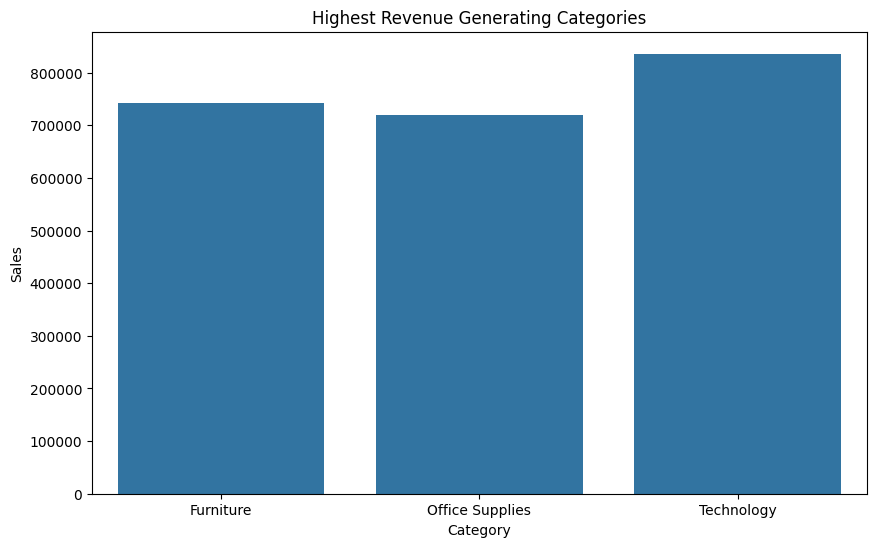

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar chart of sales by category
plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Sales', data=category_sales)
plt.title('Highest Revenue Generating Categories')
plt.show()

### 💡 Category Performance Analysis
* **Technology is the Star Performer:** While sales are relatively balanced across all three segments, **Technology** leads total revenue at **$836,154**, followed closely by Furniture ($741,999) and Office Supplies ($719,047).
* **The Profitability Warning Sign:** Although **Furniture** generates a high volume of sales, its profit margin is extremely thin compared to the other two categories.
* **Strategic Recommendation:** Management should focus marketing efforts and promotional budget on *Technology* and *Office Supplies* to maximize bottom-line profit margins, rather than chasing low-margin volume in *Furniture*.

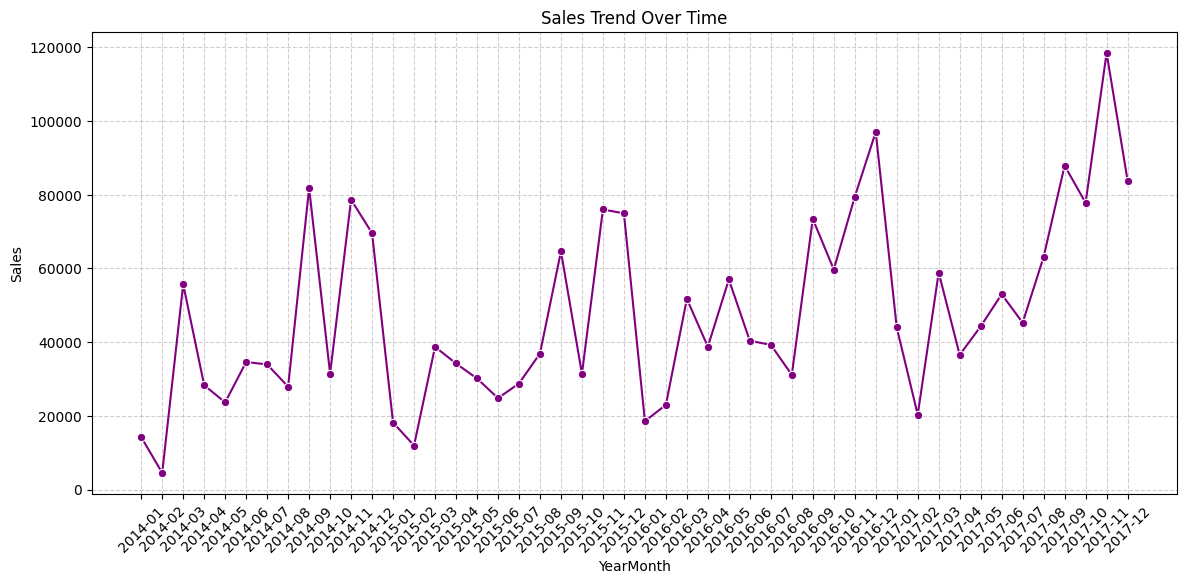

In [19]:
# 1. Convert Order Date to standard datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Extract Year and Month for chronological sorting
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# 3. Group by Month and sum sales
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

# 4. Convert YearMonth back to string format just for plotting
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# 5. Plot the trend
plt.figure(figsize=(14, 6))
sns.lineplot(x='YearMonth', y='Sales', data=monthly_sales, marker='o', color='purple')
plt.title('Sales Trend Over Time')
plt.xticks(rotation=45) # Tilts dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6) # Adds a clean background grid
plt.show()

### 🗓️ Seasonal Trends & Sales Velocity
* **Q4 Holiday Spikes:** The line chart reveals a clear, predictable seasonal pattern. Sales skyrocket during the final months of every year, with **November 2017** hitting an all-time record peak of **$118,447**. September also shows recurring spikes across multiple fiscal years.
* **Q1 Slump:** Conversely, January and February consistently represent the slowest operational periods of the year.
* **Strategic Recommendation:** 1. Optimize inventory levels and increase staffing capacity starting in late August to prepare for the September and Q4 surges.
  2. Plan aggressive customer engagement and clearing campaigns during January to offset the post-holiday sales dip.

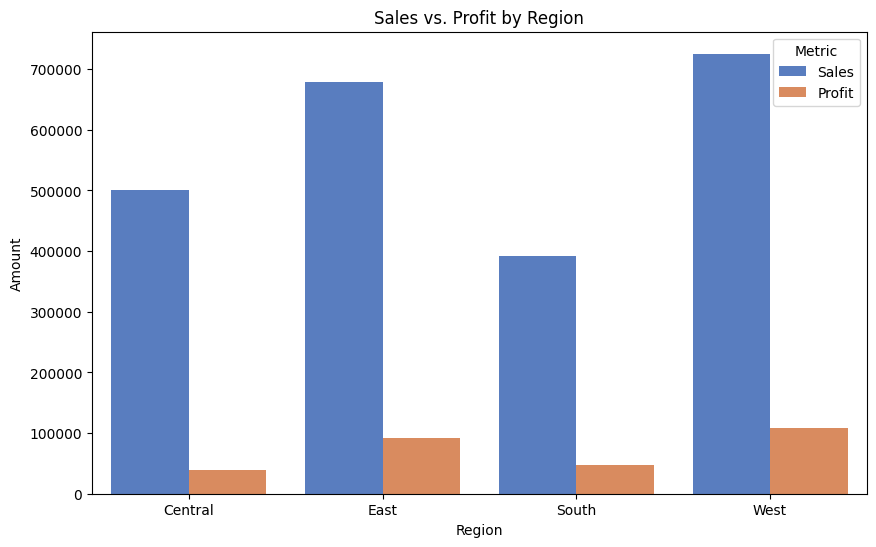

In [20]:
# Group by Region and calculate both total Sales and total Profit
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

# Melt the dataframe to make it easy for Seaborn to plot side-by-side bars
region_melted = pd.melt(region_analysis, id_vars='Region', value_vars=['Sales', 'Profit'],
                        var_name='Metric', value_name='Amount')

# Plot side-by-side comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Amount', hue='Metric', data=region_melted, palette='muted')
plt.title('Sales vs. Profit by Region')
plt.show()

### 📍 Regional Market Health Check
* **The West Coast Leader:** The **West Region** is the most lucrative territory, producing both the highest total sales (**$725,457**) and the strongest absolute profits (**$108,418**) at an impressive ~15% profit margin.
* **The Central Region Concern:** While the **Central Region** manages to achieve strong gross sales ($501,239), it suffers from severe margin leakages—yielding only **$39,706 in profit** (~7.9% margin, the lowest across the firm).
* **Strategic Recommendation:** Run an operational audit on the Central territory. The low profitability points toward excessive shipping costs, high local discounts, or suboptimal product distributions that need immediate adjustment.

/tmp/ipykernel_1490/1822701088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=top_products, palette='Blues_r')


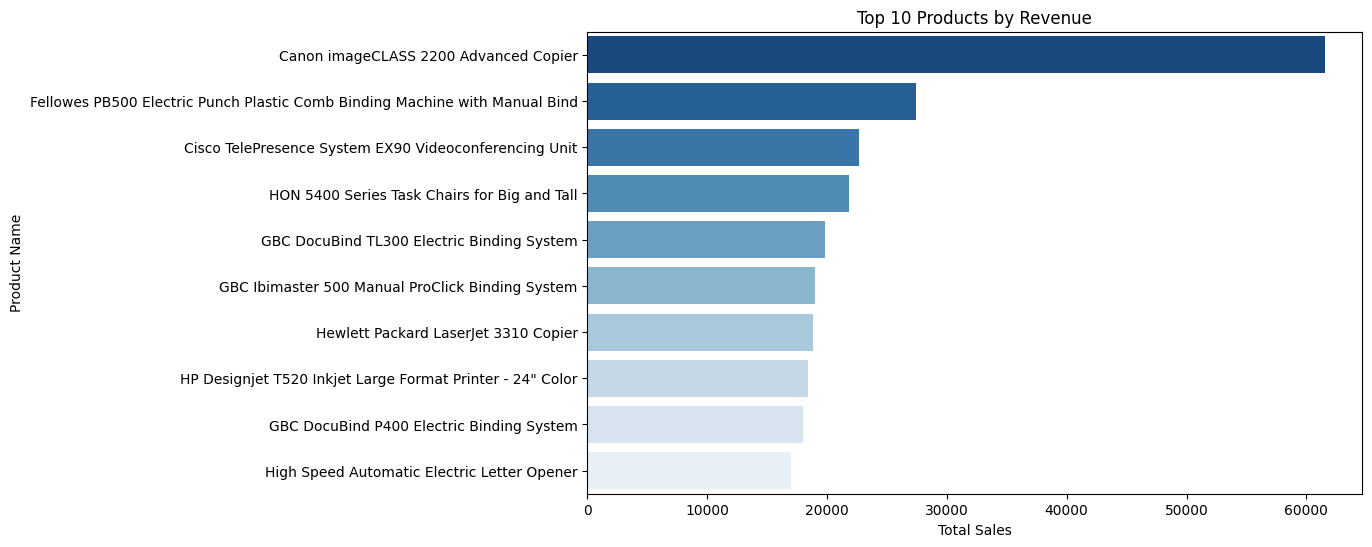

In [21]:
# Group by Product Name, sum sales, and grab the top 10
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()
top_products = top_products.sort_values(by='Sales', ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Sales', y='Product Name', data=top_products, palette='Blues_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.show()

### 📦 Core Product Portfolio Drivers
* **The Revenue Engine:** A single product—the **Canon imageCLASS 2200 Advanced Copier**—dominates the catalog, generating a staggering **$61,599** in revenue, far outperforming any other item.
* **Key Categories:** High-value business electronics (Copiers, Videoconferencing units) and corporate furniture (Task Chairs) dominate the Top 10 items.
* **Strategic Recommendation:** 1. Protect the supply chain for these top 10 items; stockouts on key high-ticket items like the Canon Copier directly damage top-line revenue.
  2. Implement a cross-selling algorithm on the digital storefront to suggest complementary Office Supplies (paper, ink, accessories) whenever these flagship products are purchased.